   CustomerID  Recency  Frequency  Monetary  Cluster
0           1       52         45      4844        0
1           2       93         41      4513        0
2           3       15         29      3848        2
3           4       72         15      4879        0
4           5       61         45       763        1


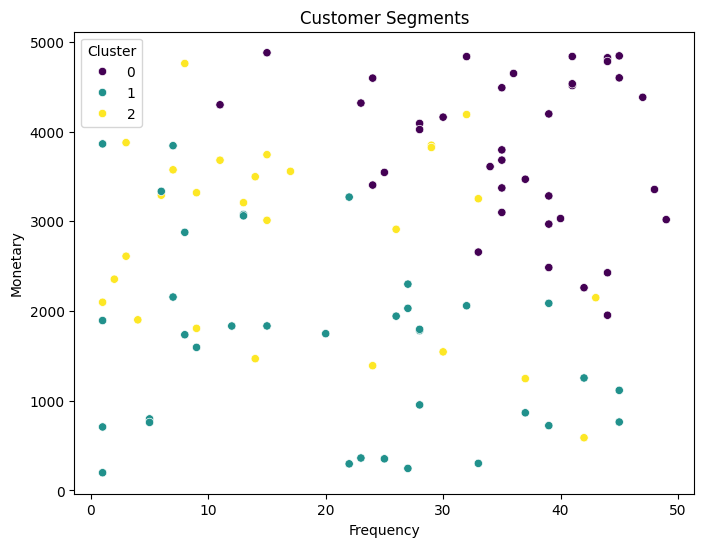

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
data = {
    'CustomerID': range(1,101),
    'Recency': np.random.randint(1,100,100),
    'Frequency': np.random.randint(1,50,100),
    'Monetary': np.random.randint(100,5000,100)

}
df = pd.DataFrame(data)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Recency', 'Frequency', 'Monetary']])
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)
print(df.head())
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Frequency', y='Monetary', hue='Cluster', palette='viridis')
plt.title('Customer Segments')
plt.show()

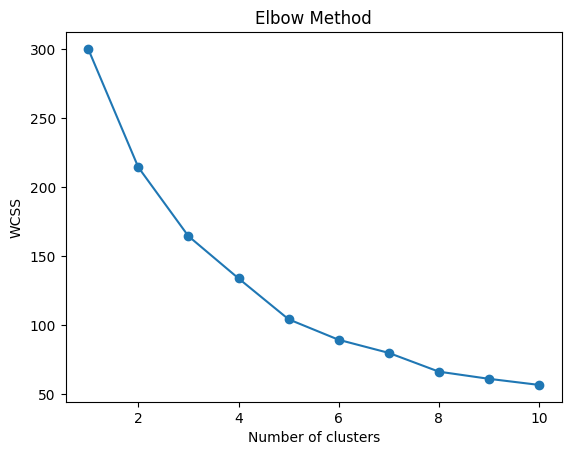

In [10]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(scaled_features)
  wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

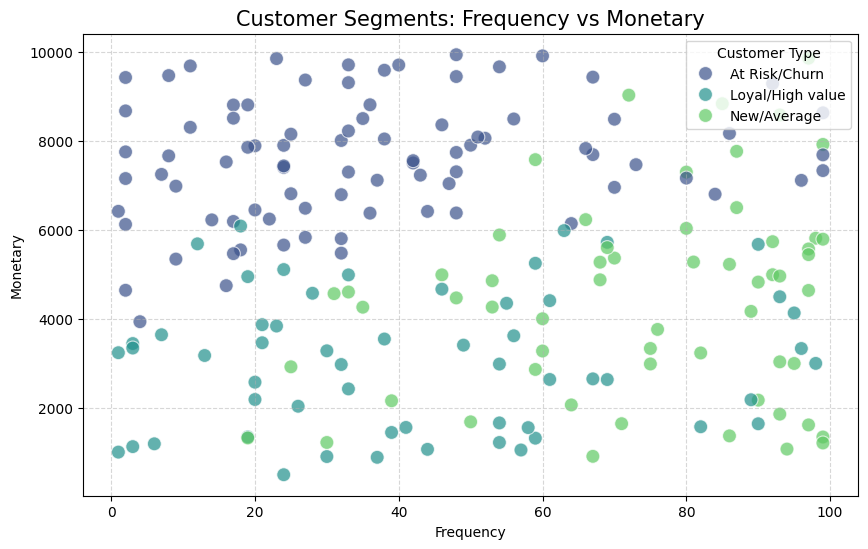


--- Cluster Summary Statistics ---


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n_customers = 200
data = {
    'CustomerID': range(1, n_customers + 1),
    'Recency': np.random.randint(1,365, n_customers),
    'Frequency': np.random.randint(1,100, n_customers),
    'Monetary': np.random.randint(500,10000,n_customers)
}
df = pd.DataFrame(data)
features = ['Recency','Frequency','Monetary']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

cluster_map = {
    0: "Loyal/High value",
    1: "At Risk/Churn",
    2: "New/Average"

}
df['Segment'] = df['Cluster'].map(cluster_map)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Customer Segments: Frequency vs Monetary', fontsize=15)
plt.legend(title='Customer Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

summary = df.groupby('Segment')[['Recency', 'Frequency', 'Monetary']]
print("\n--- Cluster Summary Statistics ---")
print(summary)

In [14]:
df.to_csv('Customer_Segments.csv', index=False)
print("File Saved!")

File Saved!
